# Recurrent Neural Network (RNN)

Implementations of:
1) Vanilla RNN (SimpleRNN)
2) Deep/Stacked RNN
3) Bidirectional RNN
4) Stateful RNN

Install & Import

In [144]:
!pip install yfinance

In [145]:
# Importing necessary libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Bidirectional
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import Adam

Load Stock Market Dataset

In [146]:
# Load last 5 years of Apple stock data
df = yf.download("AAPL", period="5y", auto_adjust=True)[['Close']]
df.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2020-12-14,118.547028
2020-12-15,124.485077
2020-12-16,124.416939
2020-12-17,125.283302
2020-12-18,123.297470
2020-12-21,124.825790
2020-12-22,128.378891
2020-12-23,127.483330


In [147]:
df.shape

(1256, 1)

Preprocess the Data

In [148]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
scaled_data

array([[0.0295622 ],
       [0.06393589],
       [0.06354145],
       ...,
       [0.95710558],
       [0.95276404],
       [0.95421122]])

In [149]:
# create dataset sequences
def create_sequences(data, window=30):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X), np.array(y)

window_size = 30
X, y = create_sequences(scaled_data, window=window_size)


In [150]:
X.shape

(1226, 30, 1)

In [151]:
y.shape

(1226, 1)

In [152]:
# train-test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [153]:
X_train.shape

(980, 30, 1)

In [154]:
X_test.shape

(246, 30, 1)

In [155]:
y_train.shape

(980, 1)

In [156]:
y_test.shape

(246, 1)

In [157]:
X[0]

array([[0.0295622 ],
       [0.06393589],
       [0.06354145],
       [0.06855659],
       [0.05706117],
       [0.06590818],
       [0.08647608],
       [0.08129193],
       [0.08698335],
       [0.11358066],
       [0.1033248 ],
       [0.09684438],
       [0.09104038],
       [0.07255753],
       [0.08157361],
       [0.05672309],
       [0.08106625],
       [0.087434  ],
       [0.07013427],
       [0.06912013],
       [0.08089727],
       [0.06974002],
       [0.05976602],
       [0.06365425],
       [0.08732112],
       [0.11459476],
       [0.12699224],
       [0.14868695],
       [0.15003926],
       [0.14384061]])

In [158]:
y[0]

array([0.11583472])

In [159]:
X[30]

array([[0.11583472],
       [0.08692699],
       [0.09921141],
       [0.10400104],
       [0.09808416],
       [0.11752525],
       [0.11512676],
       [0.11597313],
       [0.11089405],
       [0.10739508],
       [0.10592785],
       [0.10728219],
       [0.09497958],
       [0.08171732],
       [0.07534024],
       [0.07624314],
       [0.05440313],
       [0.05361303],
       [0.05073475],
       [0.02612921],
       [0.02765301],
       [0.0645049 ],
       [0.04943676],
       [0.03216781],
       [0.02127585],
       [0.02855582],
       [0.        ],
       [0.02669359],
       [0.02042957],
       [0.03160339]])

In [160]:
X[1]

array([[0.06393589],
       [0.06354145],
       [0.06855659],
       [0.05706117],
       [0.06590818],
       [0.08647608],
       [0.08129193],
       [0.08698335],
       [0.11358066],
       [0.1033248 ],
       [0.09684438],
       [0.09104038],
       [0.07255753],
       [0.08157361],
       [0.05672309],
       [0.08106625],
       [0.087434  ],
       [0.07013427],
       [0.06912013],
       [0.08089727],
       [0.06974002],
       [0.05976602],
       [0.06365425],
       [0.08732112],
       [0.11459476],
       [0.12699224],
       [0.14868695],
       [0.15003926],
       [0.14384061],
       [0.11583472]])

In [161]:
y[1]

array([0.08692699])

In [162]:
X[31]

array([[0.08692699],
       [0.09921141],
       [0.10400104],
       [0.09808416],
       [0.11752525],
       [0.11512676],
       [0.11597313],
       [0.11089405],
       [0.10739508],
       [0.10592785],
       [0.10728219],
       [0.09497958],
       [0.08171732],
       [0.07534024],
       [0.07624314],
       [0.05440313],
       [0.05361303],
       [0.05073475],
       [0.02612921],
       [0.02765301],
       [0.0645049 ],
       [0.04943676],
       [0.03216781],
       [0.02127585],
       [0.02855582],
       [0.        ],
       [0.02669359],
       [0.02042957],
       [0.03160339],
       [0.02635493]])

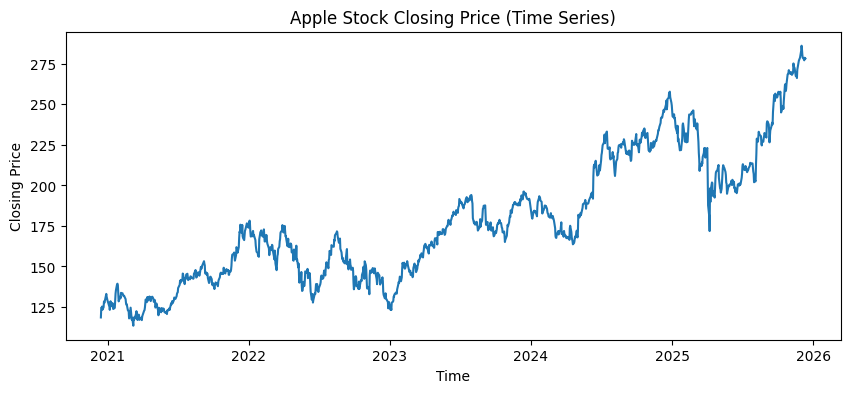

In [163]:
plt.figure(figsize=(10,4))
plt.plot(df['Close'])
plt.title("Apple Stock Closing Price (Time Series)")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.show()

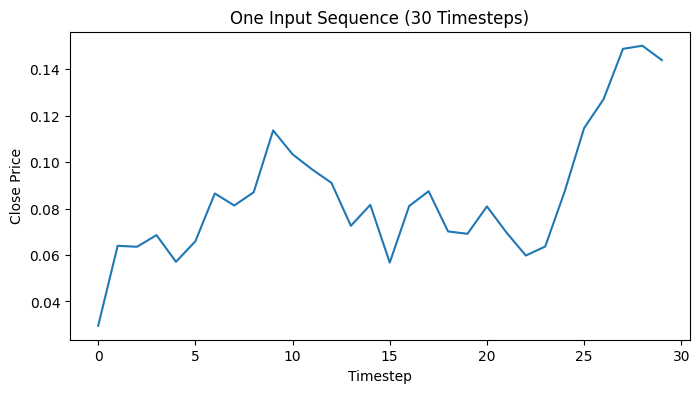

In [164]:
plt.figure(figsize=(8,4))
plt.plot(X[0])
plt.title("One Input Sequence (30 Timesteps)")
plt.xlabel("Timestep")
plt.ylabel("Close Price")
plt.show()

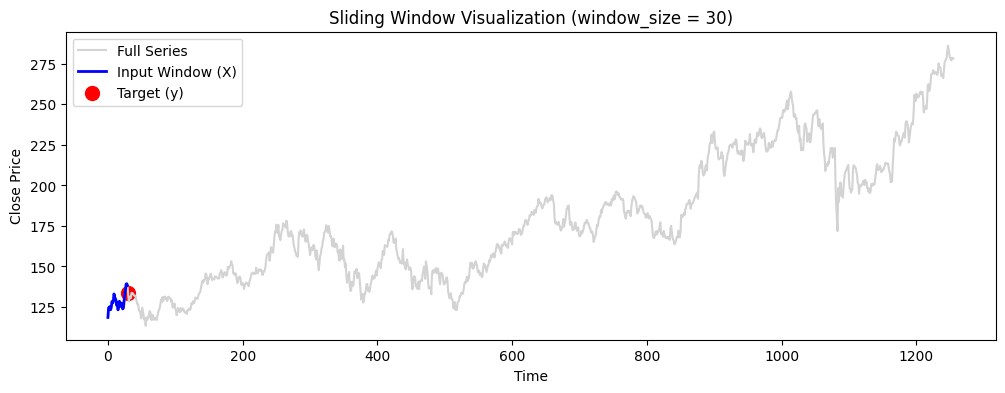

In [165]:
# Choose a sample index
i = 30

window_size = 30

plt.figure(figsize=(12,4))

# Full series
plt.plot(df['Close'].values, color='lightgray', label="Full Series")

# Sliding window (X)
plt.plot(range(i-window_size, i),df['Close'].values[i-window_size:i],color='blue',linewidth=2,label="Input Window (X)")

# Target value (y)
plt.scatter(i,df['Close'].values[i],color='red',s=100,label="Target (y)")
plt.title("Sliding Window Visualization (window_size = 30)")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

1) VANILLA RNN (SimpleRNN)

In [166]:
model_rnn = Sequential([SimpleRNN(50, return_sequences=False, input_shape=(window_size, 1)),Dense(1)])

model_rnn.compile(optimizer="adam", loss="mse")
model_rnn.summary()

history_rnn = model_rnn.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_20 (SimpleRNN)       │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0120 - val_loss: 0.0098
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0014 - val_loss: 0.0036
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7813e-04 - val_loss: 0.0029
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 7.4923e-04 - val_loss: 0.0030
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.3289e-04 - val_loss: 0.0022
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.1622e-04 - val_loss: 0.0020
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.7405e-04 - val_loss: 0.0021
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.9619e-04 - val_loss: 0.0020
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.8253e-04 - val_loss: 0.0017
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.5884e-04 - val_loss: 0.0015


SimpleRNN Parameter Formula:

Parameters=(Input features×Hidden units)+(Hidden units×Hidden units)+(Hidden units)=(1×50)+(50×50)+50=50+2500+50=2600

Dense Layer Formula:
Parameters=(Input units×Output units)+(Output units)=(50×1)+1=51

Prediction

In [167]:
# Model Prediction
prediction = model_rnn.predict(X_test)
prediction = scaler.inverse_transform(prediction)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [168]:
actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
    print(f"Predicted: {prediction[i][0]:.2f}, Actual: {actual[i][0]:.2f}")


Predicted: 246.46, Actual: 248.67
Predicted: 246.80, Actual: 253.34
Predicted: 249.54, Actual: 254.12
Predicted: 249.03, Actual: 257.04
Predicted: 250.63, Actual: 257.85
Predicted: 253.26, Actual: 254.44
Predicted: 252.24, Actual: 251.06
Predicted: 252.14, Actual: 249.29
Predicted: 252.08, Actual: 242.75
Predicted: 246.05, Actual: 242.26
Predicted: 244.36, Actual: 243.90
Predicted: 243.69, Actual: 241.12
Predicted: 239.81, Actual: 241.61
Predicted: 240.23, Actual: 235.78
Predicted: 239.15, Actual: 233.34
Predicted: 236.04, Actual: 232.23
Predicted: 235.38, Actual: 236.80
Predicted: 236.02, Actual: 227.23
Predicted: 230.24, Actual: 228.94
Predicted: 231.44, Actual: 221.64
Predicted: 227.93, Actual: 222.82
Predicted: 225.79, Actual: 222.65
Predicted: 224.73, Actual: 221.78
Predicted: 223.42, Actual: 228.83
Predicted: 223.77, Actual: 237.19
Predicted: 230.25, Actual: 238.28
Predicted: 230.97, Actual: 236.52
Predicted: 233.97, Actual: 234.94
Predicted: 236.63, Actual: 226.98
Predicted: 233

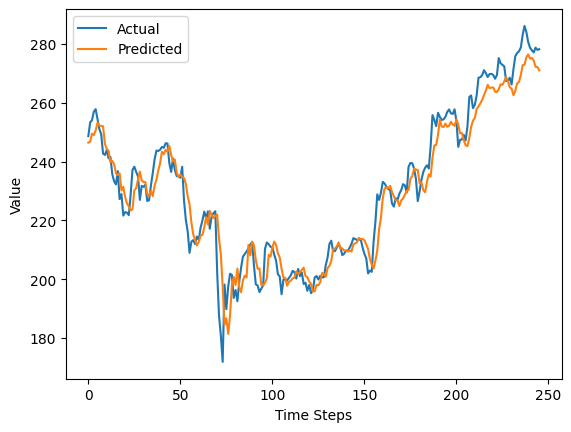

In [169]:
# Plotting (Actual vs Predicted values)
plt.figure()
plt.plot(actual, label="Actual")
plt.plot(prediction, label="Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.show()


2) DEEP / STACKED RNN

In [170]:
model_deep_rnn = Sequential([SimpleRNN(50, return_sequences=True, input_shape=(window_size, 1)),SimpleRNN(50),Dense(1)])

model_deep_rnn.compile(optimizer="adam", loss="mse")
model_deep_rnn.summary()

history_deep = model_deep_rnn.fit(X_train, y_train, epochs=10, batch_size=32,validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_21 (SimpleRNN)       │ (None, 30, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_22 (SimpleRNN)       │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0606 - val_loss: 0.0197
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0023 - val_loss: 0.0047
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.2377e-04 - val_loss: 0.0033
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.1196e-04 - val_loss: 0.0026
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.6394e-04 - val_loss: 0.0026
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.0150e-04 - val_loss: 0.0023
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.0767e-04 - val_loss: 0.0021
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.7576e-04 - val_loss: 0.0019
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.4299e-04 - val_loss: 0.0018


3) BIDIRECTIONAL RNN

In [171]:
model_birnn = Sequential([Bidirectional(SimpleRNN(50), input_shape=(window_size, 1)),Dense(1)])

model_birnn.compile(optimizer="adam", loss="mse")
model_birnn.summary()

history_bi = model_birnn.fit(X_train, y_train, epochs=10, batch_size=32,validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 100)            │         5,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,301 (20.71 KB)

 Trainable params: 5,301 (20.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0458 - val_loss: 0.0121
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - val_loss: 0.0046
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7.5447e-04 - val_loss: 0.0037
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.3068e-04 - val_loss: 0.0033
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.1176e-04 - val_loss: 0.0027
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.0305e-04 - val_loss: 0.0027
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.3964e-04 - val_loss: 0.0022
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4.2068e-04 - val_loss: 0.0020
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4.6229e-04 - val_loss: 0.0021
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.8350e-04 - val_loss: 0.0018


4) STATEFUL RNN

In [172]:
batch = 32

model_stateful = Sequential([Input(batch_shape=(batch, window_size, 1)),SimpleRNN(50, stateful=True),Dense(1)])

model_stateful.compile(optimizer="adam", loss="mse")
model_stateful.summary()


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_24 (SimpleRNN)       │ (32, 50)               │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (32, 1)                │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [173]:
batch = 32

train_len = len(X_train) - (len(X_train) % batch)

X_train_s = X_train[:train_len]
y_train_s = y_train[:train_len]

print("Trimmed training shape:", X_train_s.shape)


Trimmed training shape: (960, 30, 1)


In [174]:
train_len

960

In [175]:
stateful_losses = []

for epoch in range(10):
    print(f"Epoch: {epoch+1}")

    history = model_stateful.fit(X_train_s,y_train_s,batch_size=batch,epochs=1,shuffle=False)

    # Store loss
    stateful_losses.append(history.history['loss'][0])

    # Reset RNN states after each epoch
    for layer in model_stateful.layers:
        if hasattr(layer, "reset_states"):
            layer.reset_states()

Epoch: 1
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0053
Epoch: 2
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032
Epoch: 3
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018
Epoch: 4
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.8870e-04
Epoch: 5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015
Epoch: 6
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.9570e-04
Epoch: 7
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.2536e-04
Epoch: 8
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3174e-04
Epoch: 9
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.5401e-04
Epoch: 10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.9693e-04


Plot Loss Curves

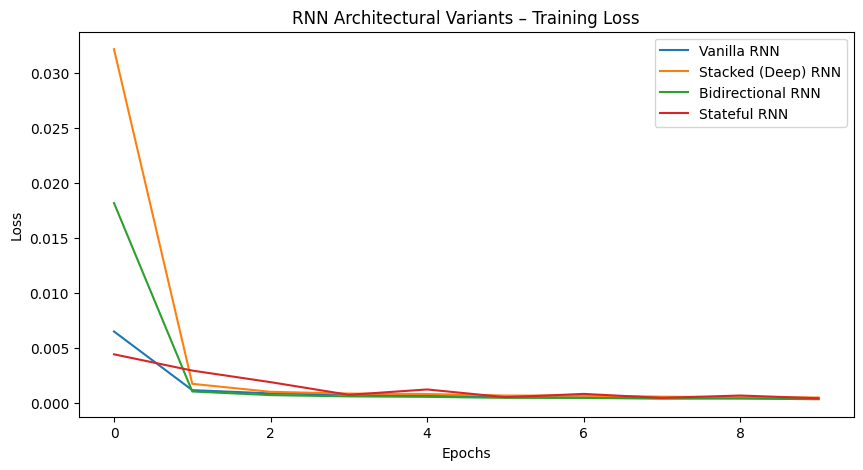

In [176]:
plt.figure(figsize=(10,5))
plt.plot(history_rnn.history['loss'], label='Vanilla RNN')
plt.plot(history_deep.history['loss'], label='Stacked (Deep) RNN')
plt.plot(history_bi.history['loss'], label='Bidirectional RNN')
plt.plot(stateful_losses, label='Stateful RNN')

plt.title("RNN Architectural Variants – Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()